# Isotropic 2PCF Benchmark: PyHermes vs pycorr vs TreeCorr

This notebook benchmarks isotropic two-point correlation measurements on the same Quijote halo catalogue. Benchmark summaries are written under `examples/output`, and comparison figures are written under `examples/figs`. The goal is to compare wall-clock cost and output curves under a clear and reproducible setup, not to claim that one package universally replaces another.

Benchmark modes:

- **PyHermes projection**: project the loaded `pos` array directly to `ConvolsData` fields at several resolutions, here `J=7,8,9`.
- **PyHermes 2PCF**: compute the finite-bin shell-window 2PCF from each projected field.
- **pycorr**: compute conventional radial `s`-binned 2PCF using pycorr.
- **TreeCorr**: compute 3D radial pair counts; optionally compute RR and xi with a random catalogue.

All three methods use the same radial bin edges. PyHermes represents each finite bin by a volume-normalized difference of two spherical top-hat windows, then reports the value at the corresponding bin center for plotting. Comparing `J=7,8,9` helps separate true estimator differences from the finite-resolution smoothing of the PyHermes field representation.


In [1]:
from pathlib import Path
import importlib
import json
import os
import platform
import resource
import sys
import time

import numpy as np
import pandas as pd

# Make the notebook robust whether it is launched from the repo root,
# examples/, or examples/notebooks/.
START_DIR = Path.cwd().resolve()
ROOT = next((path for path in (START_DIR, *START_DIR.parents) if (path / 'pyhermes').exists()), None)
if ROOT is None:
    raise RuntimeError(f'Could not locate the PyHermes repository root from {START_DIR}')
EXAMPLES = ROOT / 'examples'
os.chdir(EXAMPLES)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT =', ROOT)
print('working directory =', Path.cwd())
print('examples directory =', EXAMPLES)


ROOT = /Users/xutengpeng/xutp/PycharmProjects/PyHermes
working directory = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples
examples directory = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## Configuration

For quick smoke tests, set `N_MAX` to a smaller number such as `50_000`. For final benchmarks, keep `N_MAX=None` and run on the full halo sample. If TreeCorr is used with RR, `TREECORR_RANDOM_FACTOR=1.0` gives a random catalogue with the same size as the data catalogue. All finite-bin estimators use `S_EDGES`; PyHermes uses the bin centers only as sampling labels and maps each center back to its exact inner and outer bin edges.


In [2]:
BOX_SIZE = 1000.0
THREADS = 8
RANDOM_SEED = 12345
N_MAX = None  # e.g. 50_000 for a fast smoke test; None uses the full halo sample.

S_BIN_MIN = 5.0
S_BIN_MAX = 150.0
N_BINS = 31
S_EDGES = np.linspace(S_BIN_MIN, S_BIN_MAX, N_BINS + 1)
# pycorr, TreeCorr, and PyHermes use the same finite radial bins. PyHermes
# reports the binned-shell measurements at these bin centers for plotting.
S_SAMPLES = 0.5 * (S_EDGES[:-1] + S_EDGES[1:])
N_SAMPLES = len(S_SAMPLES)

PYHERMES_J_VALUES = [7, 8, 9]
RUN_PYHERMES = True
REBUILD_PYHERMES_FIELDS = True  # Build each ConvolsData field directly from the loaded pos array.
RUN_PYCORR = True
RUN_TREECORR_DD = True
RUN_TREECORR_RR = False
TREECORR_RANDOM_FACTOR = 1.0

DATA_PATH = EXAMPLES / 'data/quijote_halos/8000/groups_004/group_tab_004.pos.npz'
OUTPUT_DIR = EXAMPLES / 'output'
FIGS_DIR = EXAMPLES / 'figs'
RESULT_JSON = OUTPUT_DIR / 'benchmark_2pcf_isotropic_compare.json'
RESULT_CSV = OUTPUT_DIR / 'benchmark_2pcf_isotropic_compare.csv'

print('N_SAMPLES =', N_SAMPLES)
print('bin range =', (float(S_EDGES[0]), float(S_EDGES[-1])))
print('PyHermes binned-shell center range =', (float(S_SAMPLES.min()), float(S_SAMPLES.max())))
print('PyHermes J values =', PYHERMES_J_VALUES)
print('data =', DATA_PATH)


N_SAMPLES = 31
bin range = (5.0, 150.0)
PyHermes binned-shell center range = (7.338709677419355, 147.66129032258067)
PyHermes J values = [7, 8, 9]
data = /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/data/quijote_halos/8000/groups_004/group_tab_004.pos.npz


In [3]:
def optional_import(name):
    try:
        module = importlib.import_module(name)
        return module, None
    except Exception as exc:
        return None, exc


def maxrss_mb():
    """Return current process maximum resident set size in MB.

    macOS reports ru_maxrss in bytes, Linux reports it in KiB. The heuristic below
    keeps the value readable on both systems.
    """
    value = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    if platform.system() == 'Darwin':
        return value / 1024**2
    return value / 1024


def benchmark(label, func, **meta):
    print(f'\n--- {label} ---')
    start_mem = maxrss_mb()
    t0 = time.perf_counter()
    try:
        value = func()
        status = 'ok'
        error = ''
    except Exception as exc:
        value = None
        status = 'failed'
        error = repr(exc)
        print('FAILED:', error)
    t1 = time.perf_counter()
    end_mem = maxrss_mb()
    row = {
        'label': label,
        'status': status,
        'wall_time_s': t1 - t0,
        'maxrss_mb_after': end_mem,
        'maxrss_mb_delta': max(0.0, end_mem - start_mem),
        'error': error,
        **meta,
    }
    print({k: row[k] for k in ['status', 'wall_time_s', 'maxrss_mb_after', 'maxrss_mb_delta']})
    return row, value


def save_results(rows):
    RESULT_JSON.parent.mkdir(parents=True, exist_ok=True)
    with RESULT_JSON.open('w') as f:
        json.dump(rows, f, indent=2)
    pd.DataFrame(rows).to_csv(RESULT_CSV, index=False)
    print('saved:', RESULT_JSON)
    print('saved:', RESULT_CSV)

## Load catalogue

The benchmark uses the Quijote fiducial halo catalogue stored in `examples/data`. The default full sample contains 406728 halos.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
data = np.load(DATA_PATH)
pos_all = np.asarray(data['pos'], dtype=np.float64)
pos = pos_all
if N_MAX is not None and N_MAX < len(pos_all):
    idx = rng.choice(len(pos_all), size=int(N_MAX), replace=False)
    pos = pos_all[idx]
pos = np.ascontiguousarray(pos)
CATALOG_TAG = f'N{len(pos)}' if len(pos) != len(pos_all) else 'full'


def pyhermes_convols_path(J):
    suffix = f'_J{int(J)}'
    if CATALOG_TAG != 'full':
        suffix += f'_{CATALOG_TAG}'
    return OUTPUT_DIR / f'benchmark_pyhermes_sfc{suffix}.pkl'


def pyhermes_2pcf_path(J):
    suffix = f'_J{int(J)}'
    if CATALOG_TAG != 'full':
        suffix += f'_{CATALOG_TAG}'
    return OUTPUT_DIR / f'benchmark_pyhermes_2pcf_isotropic_binned_shell{suffix}.pkl'


print('N_data =', len(pos))
print('pos dtype/shape =', pos.dtype, pos.shape)
print('min/max =', pos.min(axis=0), pos.max(axis=0))
print('catalog tag =', CATALOG_TAG)
for J in PYHERMES_J_VALUES:
    print(f'PyHermes J={J}: field -> {pyhermes_convols_path(J)} | 2PCF -> {pyhermes_2pcf_path(J)}')


N_data = 406728
pos dtype/shape = float64 (406728, 3)
min/max = [0.00354369 0.00456209 0.00199463] [999.99499512 999.99981689 999.99743652]
catalog tag = full
PyHermes J=7: field -> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_sfc_J7.pkl | 2PCF -> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_2pcf_isotropic_binned_shell_J7.pkl
PyHermes J=8: field -> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_sfc_J8.pkl | 2PCF -> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_2pcf_isotropic_binned_shell_J8.pkl
PyHermes J=9: field -> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_sfc_J9.pkl | 2PCF -> /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_2pcf_isotropic_binned_shell_J9.pkl


## PyHermes benchmark

For each resolution `J`, PyHermes first constructs a fresh `ConvolsData` field from the already loaded `pos` array. This avoids mixing in an older precomputed SFC file and keeps the PyHermes, pycorr, and TreeCorr benchmarks tied to exactly the same catalogue. The subsequent 2PCF step uses the same finite radial bins as the pair-counting codes.


In [5]:
from numba import njit

from pyhermes.base.convols import Convols
from pyhermes.theory.corr2pcf import Corr_2PCF
from pyhermes.utils.window_functions import window_function_sphere_numba

rows = []
outputs = {}


@njit
def window_function_binned_shell_numba(ki, kj, kk, R_in, R_out):
    # Finite spherical shell: normalized difference of two spherical top-hats.
    V_in = R_in**3
    V_out = R_out**3
    denom = V_out - V_in
    if denom == 0.0:
        k = np.sqrt(ki * ki + kj * kj + kk * kk)
        q = 2.0 * np.pi * k * R_out
        if q == 0.0:
            return 1.0
        return np.sin(q) / q
    W_in = window_function_sphere_numba(ki, kj, kk, R_in)
    W_out = window_function_sphere_numba(ki, kj, kk, R_out)
    return (W_out * V_out - W_in * V_in) / denom


def mapping_s_to_binned_shell(sample, pair_window):
    s = float(sample['s'])
    idx = int(np.argmin(np.abs(S_SAMPLES - s)))
    params = dict(pair_window)
    len_args = dict(params.get('len_args', {}))
    len_args['R_in'] = float(S_EDGES[idx])
    len_args['R_out'] = float(S_EDGES[idx + 1])
    params['len_args'] = len_args
    return params


binned_shell_pair_window = {
    'type': 'binned_shell',
    'func': window_function_binned_shell_numba,
    'len_args': ['R_in', 'R_out'],
    'mapping': mapping_s_to_binned_shell,
    'kernel_mode': 'octant',
}


def run_pyhermes_projection(J):
    params = {
        'Convols': {
            # The catalogue reader is bypassed below by assigning task.particle_pos.
            # This keeps the projected field tied to the exact pos array used here.
            'box_size': BOX_SIZE,
            'J': int(J),
            'wavelet_mode': 'db2',
            'wavelet_level': 10,
            'phi_resolution': 1024,
            'threads': THREADS,
            'weight_normalization': 'catalog',
            'save_particle_data': False,
            'fout_path': str(pyhermes_convols_path(J)),
        }
    }
    task = Convols(params)
    # Use the loaded positions directly. This keeps all J values and all
    # comparison codes on exactly the same catalogue, without reading an old SFC.
    task.particle_pos = np.asarray(pos, dtype=np.float32)
    return task.run(save_result=True, overwrite=True)


def run_pyhermes_2pcf(J):
    params = {
        'Corr_2PCF': {
            'convols_data': str(pyhermes_convols_path(J)),
            'random': 'uniform',
            'pair_window': binned_shell_pair_window,
            'sampling': {'s': S_SAMPLES.tolist()},
            'products': ['xi'],
            'threads': THREADS,
            'weight_normalization': 'catalog',
            'fout_path': str(pyhermes_2pcf_path(J)),
        }
    }
    return Corr_2PCF(params).run(save_result=True, overwrite=True)


if RUN_PYHERMES:
    for J in PYHERMES_J_VALUES:
        field_path = pyhermes_convols_path(J)
        if REBUILD_PYHERMES_FIELDS or not field_path.exists():
            row, value = benchmark(
                f'pyhermes_projection_J{J}', lambda J=J: run_pyhermes_projection(J),
                code='pyhermes', task='projection', J=int(J), n_data=len(pos), n_samples=0,
                threads=THREADS, box_size=BOX_SIZE,
            )
            rows.append(row)
            outputs[f'pyhermes_projection_J{J}'] = value
        else:
            print(f'Using existing PyHermes field for J={J}: {field_path}')

        row, value = benchmark(
            f'pyhermes_xi_s_binned_shell_J{J}', lambda J=J: run_pyhermes_2pcf(J),
            code='pyhermes', task='xi_s', J=int(J), n_data=len(pos), n_samples=N_SAMPLES,
            threads=THREADS, box_size=BOX_SIZE,
        )
        rows.append(row)
        outputs[f'pyhermes_xi_s_J{J}'] = value



--- pyhermes_projection_J7 ---
15:40:43 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
15:40:43 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.J' from '8' to '7'
15:40:43 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.threads' from '1' to '8'
15:40:43 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fout_path' from 'empty' to '/Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_pyhermes_sfc_J7.pkl'
15:40:43 - INFO - pyhermes.pipeline.pipeline:Convols - Convols runtime configuration: running on 1 MPI ranks with 8 threads per rank
15:40:43 - INFO - pyhermes.pipeline.pipeline:Convols - Preparing Convols input fields ...
15:40:43 - INFO - pyhermes.pipeline.pipeline:Convols - J=7, L=128, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
15:40:43 - INFO - pyhermes.pipeline.pipeline:Convols - No catalog_weight provided; using unit catalogue weights for 406728 

## pycorr benchmark

pycorr uses finite radial bins defined by `S_EDGES`. With `boxsize` set, pycorr can use the periodic-box shortcut instead of an explicit random catalogue. Depending on the local pycorr/Corrfunc versions, extra backend compatibility options may be needed; failures are recorded in the summary rather than stopping the notebook.

In [6]:
pycorr, pycorr_error = optional_import('pycorr')


def run_pycorr_xi_s():
    from pycorr import TwoPointCorrelationFunction
    return TwoPointCorrelationFunction(
        's',
        S_EDGES,
        data_positions1=pos,
        boxsize=BOX_SIZE,
        position_type='pos',
        engine='corrfunc',
        nthreads=THREADS,
    )


if RUN_PYCORR:
    if pycorr is None:
        rows.append({
            'label': 'pycorr_xi_s', 'status': 'missing', 'wall_time_s': np.nan,
            'maxrss_mb_after': np.nan, 'maxrss_mb_delta': np.nan,
            'error': repr(pycorr_error), 'code': 'pycorr', 'task': 'xi_s',
            'n_data': len(pos), 'n_samples': len(S_EDGES) - 1,
            'threads': THREADS, 'box_size': BOX_SIZE,
        })
        print('pycorr is not available:', pycorr_error)
    else:
        print('pycorr version:', getattr(pycorr, '__version__', 'unknown'))
        row, value = benchmark(
            'pycorr_xi_s', run_pycorr_xi_s,
            code='pycorr', task='xi_s', n_data=len(pos), n_samples=len(S_EDGES) - 1,
            threads=THREADS, box_size=BOX_SIZE,
        )
        rows.append(row)
        outputs['pycorr_xi_s'] = value

pycorr version: 1.0.0

--- pycorr_xi_s ---
{'status': 'ok', 'wall_time_s': 7.093751540989615, 'maxrss_mb_after': 4048.0, 'maxrss_mb_delta': 0.0}


## TreeCorr benchmark

TreeCorr is included because it is widely used for correlation-function measurements.  For a periodic 3D box, the most direct timing is the data-data radial pair count.  If `RUN_TREECORR_RR=True`, the notebook also constructs a random catalogue and calls `calculateXi(rr=rr)`, but this adds the explicit random-pair cost and should be reported separately.

In [7]:
treecorr, treecorr_error = optional_import('treecorr')


def run_treecorr_dd():
    import treecorr
    cat = treecorr.Catalog(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2])
    nn = treecorr.NNCorrelation(
        min_sep=float(S_EDGES[0]),
        max_sep=float(S_EDGES[-1]),
        nbins=int(len(S_EDGES) - 1),
        bin_type='Linear',
        num_threads=THREADS,
        period=BOX_SIZE,
    )
    nn.process(cat, metric='Periodic')
    return nn


def run_treecorr_xi_with_rr():
    import treecorr
    n_random = int(round(TREECORR_RANDOM_FACTOR * len(pos)))
    random_pos = rng.random((n_random, 3)) * BOX_SIZE
    data_cat = treecorr.Catalog(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2])
    random_cat = treecorr.Catalog(x=random_pos[:, 0], y=random_pos[:, 1], z=random_pos[:, 2])
    kwargs = dict(
        min_sep=float(S_EDGES[0]),
        max_sep=float(S_EDGES[-1]),
        nbins=int(len(S_EDGES) - 1),
        bin_type='Linear',
        num_threads=THREADS,
        period=BOX_SIZE,
    )
    dd = treecorr.NNCorrelation(**kwargs)
    rr = treecorr.NNCorrelation(**kwargs)
    dd.process(data_cat, metric='Periodic')
    rr.process(random_cat, metric='Periodic')
    xi, varxi = dd.calculateXi(rr=rr)
    return {'dd': dd, 'rr': rr, 'xi': xi, 'varxi': varxi, 'n_random': n_random}


if RUN_TREECORR_DD or RUN_TREECORR_RR:
    if treecorr is None:
        rows.append({
            'label': 'treecorr_dd_xi_s', 'status': 'missing', 'wall_time_s': np.nan,
            'maxrss_mb_after': np.nan, 'maxrss_mb_delta': np.nan,
            'error': repr(treecorr_error), 'code': 'treecorr', 'task': 'dd_or_xi_s',
            'n_data': len(pos), 'n_samples': len(S_EDGES) - 1,
            'threads': THREADS, 'box_size': BOX_SIZE,
        })
        print('TreeCorr is not available:', treecorr_error)
    else:
        print('TreeCorr version:', getattr(treecorr, '__version__', 'unknown'))
        if RUN_TREECORR_DD:
            row, value = benchmark(
                'treecorr_dd_xi_s', run_treecorr_dd,
                code='treecorr', task='DD_s', n_data=len(pos), n_samples=len(S_EDGES) - 1,
                threads=THREADS, box_size=BOX_SIZE,
            )
            rows.append(row)
            outputs['treecorr_dd'] = value
        if RUN_TREECORR_RR:
            row, value = benchmark(
                'treecorr_xi_s_with_rr', run_treecorr_xi_with_rr,
                code='treecorr', task='xi_s_with_explicit_rr', n_data=len(pos),
                n_random=int(round(TREECORR_RANDOM_FACTOR * len(pos))),
                n_samples=len(S_EDGES) - 1, threads=THREADS, box_size=BOX_SIZE,
            )
            rows.append(row)
            outputs['treecorr_xi_s_with_rr'] = value

TreeCorr version: 5.1.3

--- treecorr_dd_xi_s ---
Unable to use multiple threads, since OpenMP is not enabled.
{'status': 'ok', 'wall_time_s': 32.36946325004101, 'maxrss_mb_after': 4048.0, 'maxrss_mb_delta': 0.0}


## Summary

The table below is the primary benchmark output. For paper use, prefer reporting `wall_time_s`, `n_data`, `n_samples`, `threads`, the PyHermes resolution `J`, and whether the row is a projection or a 2PCF timing.


In [8]:
summary = pd.DataFrame(rows)
if not summary.empty:
    display(summary)
    save_results(rows)
else:
    print('No benchmark rows were produced.')

,label,status,wall_time_s,maxrss_mb_after,maxrss_mb_delta,error,code,task,J,n_data,n_samples,threads,box_size
0,pyhermes_projection_J7,ok,0.990686,329.703125,149.593750,,pyhermes,projection,7.0,406728,0,8,1000.0
1,pyhermes_xi_s_binned_shell_J7,ok,2.159894,426.281250,96.578125,,pyhermes,xi_s,7.0,406728,31,8,1000.0
2,pyhermes_projection_J8,ok,0.267080,573.281250,147.000000,,pyhermes,projection,8.0,406728,0,8,1000.0
3,pyhermes_xi_s_binned_shell_J8,ok,12.174981,1051.093750,477.812500,,pyhermes,xi_s,8.0,406728,31,8,1000.0
4,pyhermes_projection_J9,ok,2.850592,1090.109375,39.015625,,pyhermes,projection,9.0,406728,0,8,1000.0
5,pyhermes_xi_s_binned_shell_J9,ok,132.122516,4048.000000,2957.890625,,pyhermes,xi_s,9.0,406728,31,8,1000.0
6,pycorr_xi_s,ok,7.093752,4048.000000,0.000000,,pycorr,xi_s,NaN,406728,31,8,1000.0
7,treecorr_dd_xi_s,ok,32.369463,4048.000000,0.000000,,treecorr,DD_s,NaN,406728,31,8,1000.0


saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_2pcf_isotropic_compare.json
saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_2pcf_isotropic_compare.csv


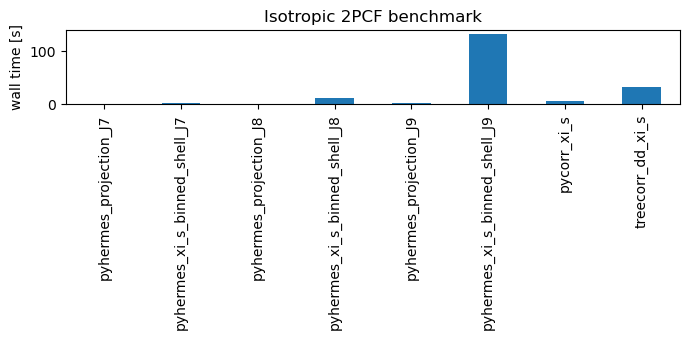

In [9]:
if not summary.empty:
    ok = summary[summary['status'].eq('ok')].copy()
    if len(ok):
        ax = ok.plot.bar(x='label', y='wall_time_s', legend=False, figsize=(7, 3.5))
        ax.set_ylabel('wall time [s]')
        ax.set_xlabel('')
        ax.set_title('Isotropic 2PCF benchmark')
        ax.figure.tight_layout()

## Curve comparison

The benchmark timings above compare runtime. The cells below also compare the measured isotropic 2PCF curves, plotted as $s^2\xi(s)$. pycorr, TreeCorr, and PyHermes use identical finite radial bins; PyHermes evaluates each bin with a binned-shell window and reports the value at the bin center. For TreeCorr, the default notebook run stores DD only, so the comparison curve uses the periodic-box analytic RR normalization, `DD / RR - 1`.


saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/figs/benchmark_2pcf_isotropic_s2xi_curves.png
saved: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples/output/benchmark_2pcf_isotropic_s2xi_curves.npz


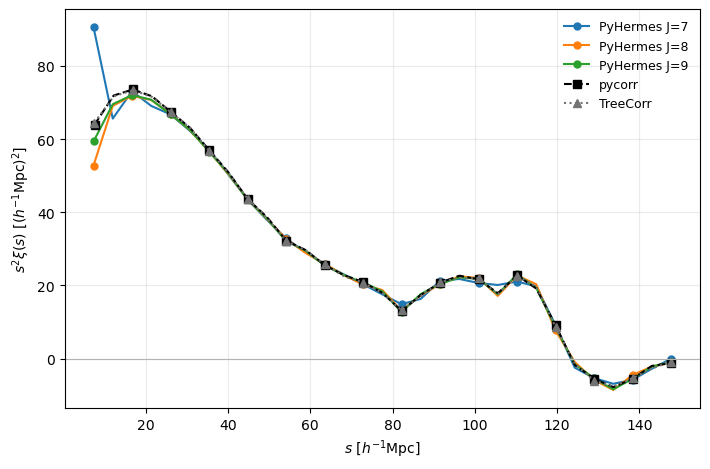

In [10]:
from pyhermes.io.corr2pcf import Corr2PCFData
import matplotlib.pyplot as plt


def pyhermes_curves():
    result = {}
    for J in PYHERMES_J_VALUES:
        value = outputs.get(f'pyhermes_xi_s_J{J}')
        path = pyhermes_2pcf_path(J)
        if value is None and path.exists():
            value = Corr2PCFData(data_path=str(path), threads=1)
        if value is None or getattr(value, 'xi', None) is None:
            continue
        result[f'PyHermes J={J}'] = (np.asarray(value.s, dtype=float), np.asarray(value.xi, dtype=float))
    return result


def pycorr_curve():
    value = outputs.get('pycorr_xi_s')
    if value is None or getattr(value, 'corr', None) is None:
        return None
    sep = getattr(value, 'sep', None)
    if sep is None:
        sep = 0.5 * (S_EDGES[:-1] + S_EDGES[1:])
    return np.asarray(sep, dtype=float), np.asarray(value.corr, dtype=float)


def treecorr_curve():
    if outputs.get('treecorr_xi_with_rr') is not None:
        value = outputs['treecorr_xi_with_rr']
        dd = value['dd']
        sep = np.asarray(getattr(dd, 'meanr', None), dtype=float)
        if sep.size == 0 or not np.any(sep > 0):
            sep = np.asarray(dd.rnom, dtype=float)
        return sep, np.asarray(value['xi'], dtype=float)

    nn = outputs.get('treecorr_dd')
    if nn is None or getattr(nn, 'npairs', None) is None:
        return None

    left = np.asarray(nn.left_edges, dtype=float)
    right = np.asarray(nn.right_edges, dtype=float)
    sep = np.asarray(getattr(nn, 'meanr', None), dtype=float)
    if sep.size == 0 or not np.any(sep > 0):
        sep = np.asarray(nn.rnom, dtype=float)

    shell_volume = 4.0 * np.pi / 3.0 * (right**3 - left**3)
    rr_pairs = 0.5 * len(pos) * (len(pos) - 1) * shell_volume / BOX_SIZE**3
    xi = np.asarray(nn.npairs, dtype=float) / rr_pairs - 1.0
    return sep, xi


def curve_key(name):
    return (
        name.replace(' ', '_')
        .replace('/', '_')
        .replace('=', '')
        .replace('(', '')
        .replace(')', '')
    )


curves = pyhermes_curves()
pycorr_value = pycorr_curve()
treecorr_value = treecorr_curve()
if pycorr_value is not None:
    curves['pycorr'] = pycorr_value
if treecorr_value is not None:
    curves['TreeCorr'] = treecorr_value

if len(curves) < 2:
    print('Need at least two successful benchmark outputs to compare curves.')
else:
    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    style_map = {
    "PyHermes J=7": dict(color="tab:blue", linestyle="-", marker="o", markersize=5),
    "PyHermes J=8": dict(color="tab:orange", linestyle="-", marker="o", markersize=5),
    "PyHermes J=9": dict(color="tab:green", linestyle="-", marker="o", markersize=5),
    "pycorr": dict(color="black", linestyle="--", marker="s", markersize=6),
    "TreeCorr": dict(color="0.45", linestyle=":", marker="^", markersize=6),
    }

    for name, (x, y) in curves.items():
        ax.plot(x, x**2 * y, linewidth=1.5, label=name, markevery=2, **style_map.get(name, {}))

    ax.axhline(0.0, color='0.7', linewidth=0.8)
    ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
    ax.set_ylabel(r'$s^2\xi(s)\ [(h^{-1}\mathrm{Mpc})^2]$')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

    fig.tight_layout()
    FIGS_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig_path = FIGS_DIR / 'benchmark_2pcf_isotropic_s2xi_curves.png'
    fig.savefig(fig_path, dpi=200, bbox_inches='tight')

    arrays_path = OUTPUT_DIR / 'benchmark_2pcf_isotropic_s2xi_curves.npz'
    np.savez(
        arrays_path,
        **{f'{curve_key(name)}_s': curve[0] for name, curve in curves.items()},
        **{f'{curve_key(name)}_xi': curve[1] for name, curve in curves.items()},
    )
    print('saved:', fig_path)
    print('saved:', arrays_path)
    plt.show()


## Interpretation notes

- The PyHermes projection rows measure catalogue-to-field construction from the loaded `pos` array, separately for each `J`.
- The PyHermes 2PCF rows measure the binned-shell correlation calculation after the corresponding field has been constructed.
- TreeCorr's DD-only timing is a pair-counting throughput measurement. If RR is enabled, report it as an explicit-random workflow.
- PyHermes uses the same finite radial bin edges as pycorr and TreeCorr, implemented as a volume-normalized difference of two spherical top-hat windows. Remaining small-scale differences should decrease as `J` increases if they are dominated by finite field resolution.
